# Identify which ligands and receptors are driving niche formation

In [1]:
import re
from collections import defaultdict
from pathlib import Path

import anndata as ad
import pandas as pd
import scanpy as sc
import squidpy as sq
import matplotlib.pyplot as plt
import niche_receptor_ligand as rl
import cell_neighbors as cn

/Users/paulinampaiz/.local/share/mamba/envs/squidpy/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/paulinampaiz/.local/share/mamba/envs/squidpy/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/Users/paulinampaiz/.local/share/mamba/envs/squidpy/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import sys
import subprocess
import numpy as np
import pandas as pd
import scanpy as sc
import anndata
from anndata import AnnData
from matplotlib import pyplot as plt
import matplotlib as mpl
import seaborn as sns
import os

import monkeybread as mb 


In [3]:
import warnings
warnings.filterwarnings("ignore")

In [5]:
%load_ext autoreload
%autoreload 
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
os.getcwd()

'/Users/paulinampaiz/Desktop/scverse_hackathon'

In [7]:
# Use gsutil to download the data from Google Cloud where the public data is stored
subprocess.run(
    "mkdir HumanMelanomaPatient2",
    shell = True
)
subprocess.run(
    "gsutil -m cp -n gs://vz-ffpe-showcase/HumanMelanomaPatient2/cell_by_gene.csv \
    gs://vz-ffpe-showcase/HumanMelanomaPatient2/cell_metadata.csv \
    ./HumanMelanomaPatient2/",
    shell = True
)

mkdir: HumanMelanomaPatient2: File exists
If you experience problems with multiprocessing on MacOS, they might be related to https://bugs.python.org/issue33725. You can disable multiprocessing by editing your .boto config or by adding the following flag to your command: `-o "GSUtil:parallel_process_count=1"`. Note that multithreading is still available even if you disable multiprocessing.

Skipping existing item: file://./HumanMelanomaPatient2/cell_metadata.csv
Skipping existing item: file://./HumanMelanomaPatient2/cell_by_gene.csv


CompletedProcess(args='gsutil -m cp -n gs://vz-ffpe-showcase/HumanMelanomaPatient2/cell_by_gene.csv     gs://vz-ffpe-showcase/HumanMelanomaPatient2/cell_metadata.csv     ./HumanMelanomaPatient2/', returncode=0)

In [8]:
adata = mb.util.load_merscope("./HumanMelanomaPatient2")

In [9]:
print(adata.obs.columns)


Index(['width', 'height', 'fov'], dtype='object')


In [10]:
# Download the file
#subprocess.run('curl -OL https://github.com/immunitastx/monkeybread/raw/main/example_data/HumanMelanomaPatient2_annotation.tsv', shell=True)

# Load the file
annot_df = pd.read_csv('./HumanMelanomaPatient2_annotation.tsv', index_col=0, sep='\t')
annot_df.index = [str(x) for x in annot_df.index]

# Add to Anndata object. Note, these annotations are provided for a filtered 
# set of cells (cells with less than 10 transcripts are not annotated and will be filterd)
adata = adata[annot_df.index]
adata.obs['Cell Type'] = pd.Categorical(
    list(annot_df['Cell Type']), 
    categories=[
        'B lineage',
        'CD4 T',
        'CD8 T',
        'Treg',
        'NK',
        'pDC',
        'cDC',
        'mregDC',
        'mono/mac',
        'granulocyte',
        'stromal',
        'malignant',
        'endothelial',
        'other'
    ], 
    ordered=True
)
adata.obs['Cell Subtype'] = list(annot_df['Cell Subtype'])

# Display the `obs` dataframe
adata.obs

,width,height,fov,Cell Type,Cell Subtype
183932,19.050605,18.497379,0,endothelial,endothelial
183936,10.547030,12.585172,0,endothelial,endothelial
183938,5.716220,4.903717,0,stromal,stromal
183939,14.804707,14.309373,0,endothelial,endothelial
183942,9.185763,19.802523,0,endothelial,endothelial
...,...,...,...,...,...
34217,9.784461,3.276215,1180,other,other
34218,9.095214,11.359051,1180,endothelial,endothelial
34219,5.500457,6.956891,1180,endothelial,endothelial
34221,7.114672,11.638629,1180,mono/mac,mono/mac (CD163-high)


In [11]:
sc.pp.normalize_total(adata, inplace=True)
sc.pp.log1p(adata)
sc.pp.pca(adata)

In [12]:
adata

AnnData object with n_obs × n_vars = 189071 × 550
    obs: 'width', 'height', 'fov', 'Cell Type', 'Cell Subtype'
    uns: 'log1p', 'pca'
    obsm: 'X_spatial', 'X_pca'
    varm: 'PCs'

## Niche analysis
We now demonstrate how to perform an analysis of cellular niches. Specifically, for each cell, we count the number of neighbors that are of each cell type thus forming a “neighborhood profile” vector of length C, where C is the number of cell types. We then cluster all neighborhood profiles and call each cluster a “niche”.

We start by defining the cell types that we will consider for our niche analysis. We will group the unclassified cells labeled as “other” together with “malignant cells” and form a new column in adata.obs for the re-names cell subtypes:

Every niche method requires a spatial neighborhood graph, which is why sq.gr.spatial_neighbors needs to be run first.

In [13]:
sq.gr.spatial_neighbors(adata, spatial_key="X_spatial", coord_type="generic", delaunay=False, n_neighs=100)
# in monkeybread they use neighborhood_profile()

In [16]:
# For each pDC, find the neighboring Tregs
cell_to_neighbors = cn.cell_neighbors(
    adata,
    groupby='Cell Type',
    group1=['mono/mac'],
    group2=['CD8 T', 'CD4 T', 'Treg'],
    radius=20
) 
cell_to_neighbors

{'63858': {'64013'},
 '63860': {'64013'},
 '63868': {'64013'},
 '63995': {'19081', '63826'},
 '19154': {'19031'},
 '29148': {'29305'},
 '29282': {'29288'},
 '29325': {'29158'},
 '59174': {'59173'},
 '59244': {'59262'},
 '59255': {'59262'},
 '59269': {'59262'},
 '59315': {'59307'},
 '59322': {'59516', '59517', '59519'},
 '59506': {'59283'},
 '59011': {'58998'},
 '42336': {'42353'},
 '60209': {'60148'},
 '42253': {'42263'},
 '42498': {'42507', '42510'},
 '42511': {'42507', '42596', '53505'},
 '42513': {'42596'},
 '42518': {'42596'},
 '53512': {'42599', '53505'},
 '53568': {'53546'},
 '53617': {'53907', '53908'},
 '53639': {'53636', '53656', '53908', '53920'},
 '53645': {'53655', '53656', '53910', '53915', '53920', '53930'},
 '53647': {'53636', '53656', '53670', '53920'},
 '53674': {'53656', '53687', '53920', '53930'},
 '53684': {'53693'},
 '53704': {'53690', '53703'},
 '53925': {'53923'},
 '53927': {'53656', '53670', '53687', '53694'},
 '53928': {'53656', '53670', '53687', '53920'},
 '53

In [18]:
lrs = mb.util.load_ligand_receptor_pairs_omnipath(adata, require_gene='CXCL9')
lrs += mb.util.load_ligand_receptor_pairs_omnipath(adata, require_gene='CXCL10')
lrs

[('CXCL9', 'CXCR3'),
 ('CXCL9', 'CCR3'),
 ('CXCL9', 'FCGR2A'),
 ('CXCL9', 'CCR5'),
 ('CXCL9', 'CXCR4'),
 ('CXCL9', 'CX3CR1'),
 ('CXCL9', 'CCR4'),
 ('CXCL9', 'CXCR1'),
 ('CXCL9', 'CCR10'),
 ('IL12B', 'CXCL9'),
 ('IL23A', 'CXCL9'),
 ('CXCL9', 'CXCR2'),
 ('IFNG', 'CXCL9'),
 ('CXCL9', 'CCR7'),
 ('CXCL9', 'CCR6'),
 ('CXCL9', 'CCR1'),
 ('CXCL9', 'XCR1'),
 ('CXCL9', 'CXCR5'),
 ('CXCL9', 'CCR2'),
 ('CXCL9', 'CCR8'),
 ('CXCL9', 'CXCR6'),
 ('CXCL10', 'CXCR3'),
 ('CXCL10', 'CCR3'),
 ('CXCL10', 'CXCR2'),
 ('CXCL10', 'CCR1'),
 ('CXCL10', 'CXCR4'),
 ('CXCL10', 'CXCR6'),
 ('CXCL10', 'CCR8'),
 ('TNF', 'CXCL10'),
 ('CXCL10', 'XCR1'),
 ('CXCL10', 'CCR5'),
 ('CXCL10', 'CCR7'),
 ('CXCL10', 'CCR6'),
 ('CXCL10', 'CCR10'),
 ('IL1B', 'CXCL10'),
 ('IFNG', 'CXCL10'),
 ('CXCL10', 'CXCR5'),
 ('CXCL10', 'CCR4'),
 ('CXCL10', 'CCR2'),
 ('CXCL10', 'CX3CR1'),
 ('CXCL10', 'CXCR1')]

In [19]:
lr_pairs = []
for g1, g2 in lrs:
    if g2 in ['CXCL9', 'CXCL10']:
        lr_pairs.append((g2, g1))
    else:
        lr_pairs.append((g1, g2))
lr_pairs

[('CXCL9', 'CXCR3'),
 ('CXCL9', 'CCR3'),
 ('CXCL9', 'FCGR2A'),
 ('CXCL9', 'CCR5'),
 ('CXCL9', 'CXCR4'),
 ('CXCL9', 'CX3CR1'),
 ('CXCL9', 'CCR4'),
 ('CXCL9', 'CXCR1'),
 ('CXCL9', 'CCR10'),
 ('CXCL9', 'IL12B'),
 ('CXCL9', 'IL23A'),
 ('CXCL9', 'CXCR2'),
 ('CXCL9', 'IFNG'),
 ('CXCL9', 'CCR7'),
 ('CXCL9', 'CCR6'),
 ('CXCL9', 'CCR1'),
 ('CXCL9', 'XCR1'),
 ('CXCL9', 'CXCR5'),
 ('CXCL9', 'CCR2'),
 ('CXCL9', 'CCR8'),
 ('CXCL9', 'CXCR6'),
 ('CXCL10', 'CXCR3'),
 ('CXCL10', 'CCR3'),
 ('CXCL10', 'CXCR2'),
 ('CXCL10', 'CCR1'),
 ('CXCL10', 'CXCR4'),
 ('CXCL10', 'CXCR6'),
 ('CXCL10', 'CCR8'),
 ('CXCL10', 'TNF'),
 ('CXCL10', 'XCR1'),
 ('CXCL10', 'CCR5'),
 ('CXCL10', 'CCR7'),
 ('CXCL10', 'CCR6'),
 ('CXCL10', 'CCR10'),
 ('CXCL10', 'IL1B'),
 ('CXCL10', 'IFNG'),
 ('CXCL10', 'CXCR5'),
 ('CXCL10', 'CCR4'),
 ('CXCL10', 'CCR2'),
 ('CXCL10', 'CX3CR1'),
 ('CXCL10', 'CXCR1')]

In [ ]:
lr_pair_to_score = rl.ligand_receptor_score(
    adata,
    cell_to_neighbors,
    lr_pairs=lr_pairs
)
lr_pair_to_score

In [ ]:
res = mb.stat.ligand_receptor_score(
    adata,
    cell_to_neighbors,
    lr_pairs=lr_pair_to_score
)

In [ ]:
res = rl.ligand_receptor_score(adata, cell_to_neighbors, lr_pair_to_score)
res


In [31]:
niche_to_cell_to_neighbors.items()

dict_items([('0', {}), ('1', {}), ('10', {'125045': {'125015'}, '93058': {'93045'}}), ('105', {}), ('106', {}), ('107', {}), ('109', {}), ('11', {'24627': {'24629', '32011', '24813', '24815', '29024', '24808'}, '24202': {'24225', '24668', '24664', '24666'}, '24230': {'24225', '24222', '24666'}, '24272': {'24283'}, '24697': {'24695', '24283'}, '16329': {'16316'}, '287': {'72449', '612', '72458', '614'}, '72494': {'72481', '291'}, '72506': {'72493'}, '72508': {'72493'}, '16201': {'16993'}, '16212': {'16993'}, '16870': {'16888'}, '17169': {'17185'}, '114349': {'114331'}, '114425': {'114420', '114429', '114381', '114397', '114404', '114447'}, '114658': {'115234'}, '114683': {'114731'}, '114704': {'114735'}, '16430': {'17096'}, '16533': {'17121', '16534', '16563', '16570'}, '16557': {'16605', '114423', '16522', '114507', '16523', '114448', '16509'}, '16786': {'115250', '16792'}, '114143': {'16258', '114970', '17017'}, '114225': {'114200'}, '16371': {'16411'}, '104618': {'104596', '105111', 

In [ ]:
res = ligand_receptor_score(adata, cell_to_neighbors, lr_pair_to_score)
res

In [35]:
# 1. Inspect niche_to_cell_to_neighbors
print("Inspecting niche_to_cell_to_neighbors:")
for niche, cell_to_neighbors in niche_to_cell_to_neighbors.items():
    print(f"\nNiche: {niche}")
    if not cell_to_neighbors:
        print("  No cells found in this niche.")
        continue
    for cell, neighbors in cell_to_neighbors.items():
        if not neighbors:
            print(f"  Cell '{cell}' has no neighbors.")
        else:
            print(f"  Cell '{cell}' has {len(neighbors)} neighbors: {neighbors}")

# 2. Validate that all cells in neighbor mapping exist in the AnnData object
missing_cells = set()
for niche, cell_to_neighbors in niche_to_cell_to_neighbors.items():
    for cell, neighbors in cell_to_neighbors.items():
        if cell not in adata.obs_names:
            missing_cells.add(cell)
        for neighbor in neighbors:
            if neighbor not in adata.obs_names:
                missing_cells.add(neighbor)

if missing_cells:
    print("\nWarning: The following cells are missing in the AnnData object:", missing_cells)
else:
    print("\nAll cells in the neighbor mapping are present in the AnnData object.")

# 3. Check the format of lr_pairs and convert to tuples if necessary
def ensure_tuple_lr_pairs(lr_pairs_input):
    # If lr_pairs is None or a single pair, wrap it in a list
    if lr_pairs_input is None:
        return None
    if isinstance(lr_pairs_input, (list, tuple)):
        # If the first element is a string, assume it's a single pair
        if lr_pairs_input and isinstance(lr_pairs_input[0], str):
            return [tuple(lr_pairs_input)]
        # Otherwise, convert each pair to a tuple
        return [tuple(pair) if isinstance(pair, list) else pair for pair in lr_pairs_input]
    raise ValueError("lr_pairs must be a tuple or a list of tuples/lists.")

# Example lr_pairs input
lr_pairs = [['CD80', 'CD28'], ['CXCL9', 'CXCR3'], ['CXCL10', 'CXCR3']]
lr_pairs = ensure_tuple_lr_pairs(lr_pairs)

print("\nLigand-Receptor pairs after conversion:")
for pair in lr_pairs:
    print(pair)


Inspecting niche_to_cell_to_neighbors:

Niche: 0
  No cells found in this niche.

Niche: 1
  No cells found in this niche.

Niche: 10
  Cell '125045' has 1 neighbors: {'125015'}
  Cell '93058' has 1 neighbors: {'93045'}

Niche: 105
  No cells found in this niche.

Niche: 106
  No cells found in this niche.

Niche: 107
  No cells found in this niche.

Niche: 109
  No cells found in this niche.

Niche: 11
  Cell '24627' has 6 neighbors: {'24629', '32011', '24813', '24815', '29024', '24808'}
  Cell '24202' has 4 neighbors: {'24225', '24668', '24664', '24666'}
  Cell '24230' has 3 neighbors: {'24225', '24222', '24666'}
  Cell '24272' has 1 neighbors: {'24283'}
  Cell '24697' has 2 neighbors: {'24695', '24283'}
  Cell '16329' has 1 neighbors: {'16316'}
  Cell '287' has 4 neighbors: {'72449', '612', '72458', '614'}
  Cell '72494' has 2 neighbors: {'72481', '291'}
  Cell '72506' has 1 neighbors: {'72493'}
  Cell '72508' has 1 neighbors: {'72493'}
  Cell '16201' has 1 neighbors: {'16993'}
  Ce

In [40]:
from typing import Optional, Union, List, Tuple, Dict, Set

def ligand_receptor_score_per_niche(
    adata: AnnData,
    niche_to_cell_to_neighbors: Dict[str, Set[str]],
    lr_pairs: Optional[Union[Tuple[str, str], List[Tuple[str, str]]]] = None,
) -> Dict[str, Dict[Tuple[str, str], float]]:
    """
    Calculates an average co-expression score of a ligand-receptor pair between neighboring cells 
    within each cellular niche. This function wraps around `ligand_receptor_score` and calls it 
    separately for each niche. If a niche has no neighbors (i.e. the mapping is empty), it returns 
    np.nan for all ligand–receptor pairs.
    
    Parameters
    ----------
    adata : AnnData
        Annotated data matrix.
    niche_to_cell_to_neighbors : dict
        Mapping from niche to cell-to-neighbors dictionaries.
    lr_pairs : tuple or list of tuples, optional
        One or more ligand–receptor pairs specified as (ligand, receptor). If a single tuple is provided,
        it is converted to a list. If `None`, you may wish to fetch pairs from Omnipath.
    
    Returns
    -------
    dict
        Dictionary mapping each niche to a sub-dictionary that maps each ligand-receptor pair to its score.
    """
    
    # Ensure lr_pairs is a list of tuples if provided.
    if lr_pairs is not None:
        if isinstance(lr_pairs, tuple):
            lr_pairs = [lr_pairs]
        else:
            # Convert any list-based pairs to tuples.
            lr_pairs = [tuple(pair) if isinstance(pair, list) else pair for pair in lr_pairs]
    
    niche_to_lr_pair_to_score = {}
    for niche, cell_to_neighbors in niche_to_cell_to_neighbors.items():
        # Check if there is at least one cell with non-empty neighbor set
        if not any(cell_to_neighbors.values()):
            # If there are no neighbor pairs, assign np.nan for all lr pairs.
            if lr_pairs is None:
                raise ValueError("lr_pairs is None and empty neighbor mapping encountered; cannot compute score.")
            lr_pair_to_score = {(ligand, receptor): np.nan for ligand, receptor in lr_pairs}
        else:
            lr_pair_to_score = ligand_receptor_score(
                adata,
                cell_to_neighbors,
                lr_pairs,
            )
        niche_to_lr_pair_to_score[niche] = lr_pair_to_score
    return niche_to_lr_pair_to_score

In [41]:
niche_to_lr_to_score = ligand_receptor_score_per_niche(
    adata,
    niche_to_cell_to_neighbors,
    lr_pairs=[['CD80', 'CD28'], ['CXCL9', 'CXCR3'], ['CXCL10', 'CXCR3']],
)
niche_to_lr_to_score

{'0': {('CD80', 'CD28'): nan,
  ('CXCL9', 'CXCR3'): nan,
  ('CXCL10', 'CXCR3'): nan},
 '1': {('CD80', 'CD28'): nan,
  ('CXCL9', 'CXCR3'): nan,
  ('CXCL10', 'CXCR3'): nan},
 '10': {('CD80', 'CD28'): np.float32(0.0),
  ('CXCL9', 'CXCR3'): np.float32(0.0),
  ('CXCL10', 'CXCR3'): np.float32(0.0)},
 '105': {('CD80', 'CD28'): nan,
  ('CXCL9', 'CXCR3'): nan,
  ('CXCL10', 'CXCR3'): nan},
 '106': {('CD80', 'CD28'): nan,
  ('CXCL9', 'CXCR3'): nan,
  ('CXCL10', 'CXCR3'): nan},
 '107': {('CD80', 'CD28'): nan,
  ('CXCL9', 'CXCR3'): nan,
  ('CXCL10', 'CXCR3'): nan},
 '109': {('CD80', 'CD28'): nan,
  ('CXCL9', 'CXCR3'): nan,
  ('CXCL10', 'CXCR3'): nan},
 '11': {('CD80', 'CD28'): np.float32(0.06820268),
  ('CXCL9', 'CXCR3'): np.float32(0.36278433),
  ('CXCL10', 'CXCR3'): np.float32(0.09932831)},
 '115': {('CD80', 'CD28'): nan,
  ('CXCL9', 'CXCR3'): nan,
  ('CXCL10', 'CXCR3'): nan},
 '116': {('CD80', 'CD28'): nan,
  ('CXCL9', 'CXCR3'): nan,
  ('CXCL10', 'CXCR3'): nan},
 '12': {('CD80', 'CD28'): nan,
  

In [42]:
adata

AnnData object with n_obs × n_vars = 189071 × 550
    obs: 'width', 'height', 'fov', 'Cell Type', 'Cell Subtype', 'nhood_niche_res=1.0'
    uns: 'log1p', 'pca', 'spatial_neighbors'
    obsm: 'X_spatial', 'X_pca'
    varm: 'PCs'
    obsp: 'spatial_connectivities', 'spatial_distances'

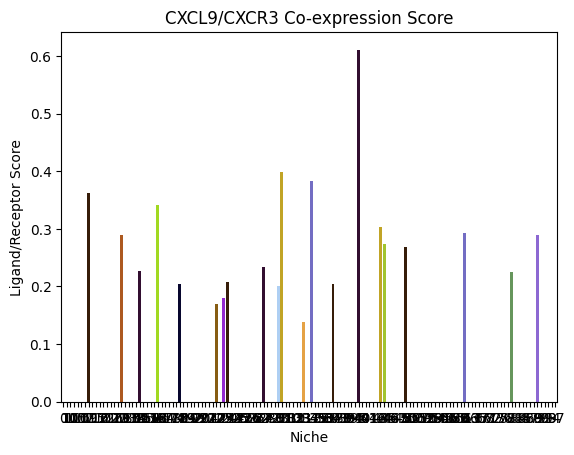

In [43]:
import itertools

# Get the unique niches from the AnnData observation
unique_niches = sorted(set(adata.obs['nhood_niche_res=1.0']))

# Extend the monkey_palette so that there is at least one color for each niche
extended_palette = list(itertools.islice(itertools.cycle(mb.plot.monkey_palette), len(unique_niches)))

niche_to_color = {val: extended_palette[i] for i, val in enumerate(unique_niches)}
# Ensure the malignant/other niche is always lightgrey
niche_to_color['malignant/other'] = 'lightgrey'

# Filter out the 'malignant/other' niche from the niches to be plotted
niches = [x for x in niche_to_lr_to_score if x != 'malignant/other']

# Plot the ligand-receptor score barplot per niche using the colors from niche_to_color
mb.plot.ligand_receptor_score_barplot_per_niche(
    niche_to_lr_to_score, 
    ('CXCL9', 'CXCR3'),
    plot_niches=niches,
    palette=[niche_to_color[x] for x in sorted(niches)]
)


In [ ]:
# Convert your dictionary to a DataFrame
df = pd.DataFrame(niche_to_lr_to_score)

# Clean the DataFrame by replacing infinities with NaN and dropping rows with NaN
df_clean = df.replace([np.inf, -np.inf], np.nan).dropna()

# If your plotting function expects a similar dictionary structure,
# you can convert it back:
niche_to_lr_to_score_clean = df_clean.to_dict()

cg = mb.plot.ligand_receptor_score_heatmap_per_niche(
    niche_to_lr_to_score_clean,
    plot_niches=niches,
    z_score=True, 
    clip_z=1, 
    cmap='bwr',
    figsize=(6,3),
    show=False
)
cg.ax_heatmap.set_xlabel('Niche')
cg.ax_heatmap.set_ylabel('Ligand/Receptor')